In [15]:
# Cell 1 - Imports
import sys
sys.path.append('/Users/drew/sports-data-portfolio')

import pandas as pd
from shared.db import get_engine
from shared.utils import ask_claude, analyze_dataframe, write_blog_post

print("Imports successful")




Imports successful


In [3]:
# Cell 2 — Connect to database and load match events
engine = get_engine()

df = pd.read_sql("""
    SELECT 
        me.id,
        me.minute,
        me.second,
        me.x,
        me.y,
        me.end_x,
        me.end_y,
        me.is_shot,
        me.is_goal,
        me.type_display_name,
        me.outcome_type_display_name,
        me.period_display_name,
        p.name as player_name,
        p.position,
        t.name as team_name,
        m.match_date,
        m.home_team_name,
        m.away_team_name
    FROM match_events me
    LEFT JOIN players p ON me.player_id = p.player_id
    LEFT JOIN teams t ON me.team_id = t.team_id
    LEFT JOIN matches m ON me.match_id::bigint = m.match_id
    LIMIT 1000
""", engine)

print(f"✅ Loaded {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Loaded 1,000 rows
Columns: ['id', 'minute', 'second', 'x', 'y', 'end_x', 'end_y', 'is_shot', 'is_goal', 'type_display_name', 'outcome_type_display_name', 'period_display_name', 'player_name', 'position', 'team_name', 'match_date', 'home_team_name', 'away_team_name']


,id,minute,second,x,y,end_x,end_y,is_shot,is_goal,type_display_name,outcome_type_display_name,period_display_name,player_name,position,team_name,match_date,home_team_name,away_team_name
0,2870872739,0,4.0,21.5,63.3,72.0,18.1,False,False,Pass,Successful,FirstHalf,Robin Roefs,GK,Sunderland,2025-11-08,Sunderland,Arsenal
1,2911348397,0,0.0,50.4,49.6,46.7,49.3,False,False,Pass,Successful,FirstHalf,Idrissa Gueye,DMC,Everton,2026-03-14,Arsenal,Everton
2,2911348623,0,12.0,53.1,22.6,73.0,30.3,False,False,Pass,Successful,FirstHalf,Jake O'Brien,DC,Everton,2026-03-14,Arsenal,Everton
3,2911348643,0,15.0,72.7,29.8,80.8,32.8,False,False,Pass,Unsuccessful,FirstHalf,Tim Iroegbunam,DMC,Everton,2026-03-14,Arsenal,Everton
4,2911348693,0,19.0,79.3,51.6,83.9,56.4,False,False,Pass,Unsuccessful,FirstHalf,Iliman Ndiaye,AML,Everton,2026-03-14,Arsenal,Everton


In [4]:
# Cell 3 — Ask Claude to analyze the data
print(analyze_dataframe(df, "What patterns do you notice in this sample of match events? What analyses would be most interesting to run on this data?"))

Looking at this football/soccer match events data, I can identify several interesting patterns and suggest compelling analyses:

## Key Patterns Observed:

**1. Data Composition:**
- Mix of events from different matches (at least 2: Sunderland vs Arsenal, Arsenal vs Everton)
- Future dates (2025-2026) suggest this might be simulated or projected data
- 71.5% of events have end coordinates (indicating movement/passes)
- Most events are passes with success/failure outcomes

**2. Spatial Patterns:**
- Coordinates appear to be on a 0-100 scale (likely percentage of pitch)
- Wide distribution across the field suggests diverse event types
- Mean positions (~48x, 49y) indicate balanced field coverage

**3. Temporal Distribution:**
- Events span 0-72 minutes with good distribution
- Includes granular timing (seconds)

## Most Interesting Analyses to Run:

### 1. **Pass Network Analysis**
```python
# Analyze team passing patterns and player connectivity
- Pass completion rates by player/positio

In [5]:
# Cell 4 — Arsenal shots only
shots_df = pd.read_sql("""
    SELECT 
        me.minute,
        me.x,
        me.y,
        me.is_goal,
        me.goal_mouth_z,
        me.goal_mouth_y,
        me.outcome_type_display_name,
        p.name as player_name,
        p.position,
        t.name as team_name,
        m.match_date,
        m.home_team_name,
        m.away_team_name
    FROM match_events me
    LEFT JOIN players p ON me.player_id = p.player_id
    LEFT JOIN teams t ON me.team_id = t.team_id
    LEFT JOIN matches m ON me.match_id::bigint = m.match_id
    WHERE me.is_shot = true
""", engine)

print(f"✅ Total shots: {len(shots_df):,}")
print(f"✅ Total goals: {shots_df['is_goal'].sum():,}")
shots_df.head()

✅ Total shots: 1,240
✅ Total goals: 156


,minute,x,y,is_goal,goal_mouth_z,goal_mouth_y,outcome_type_display_name,player_name,position,team_name,match_date,home_team_name,away_team_name
0,5,85.0,64.6,False,15.2,52.6,Successful,Noni Madueke,FWR,Arsenal,2026-03-14,Arsenal,Everton
1,7,75.9,35.8,False,19.0,51.6,Successful,Riccardo Calafiori,DL,Arsenal,2026-03-14,Arsenal,Everton
2,8,85.5,49.6,False,69.4,55.1,Successful,Riccardo Calafiori,DL,Arsenal,2026-03-14,Arsenal,Everton
3,10,85.5,60.0,False,19.0,51.4,Successful,Martín Zubimendi,MC,Arsenal,2026-03-14,Arsenal,Everton
4,10,80.8,46.8,False,2.8,38.7,Successful,Bukayo Saka,AMR,Arsenal,2026-03-14,Arsenal,Everton


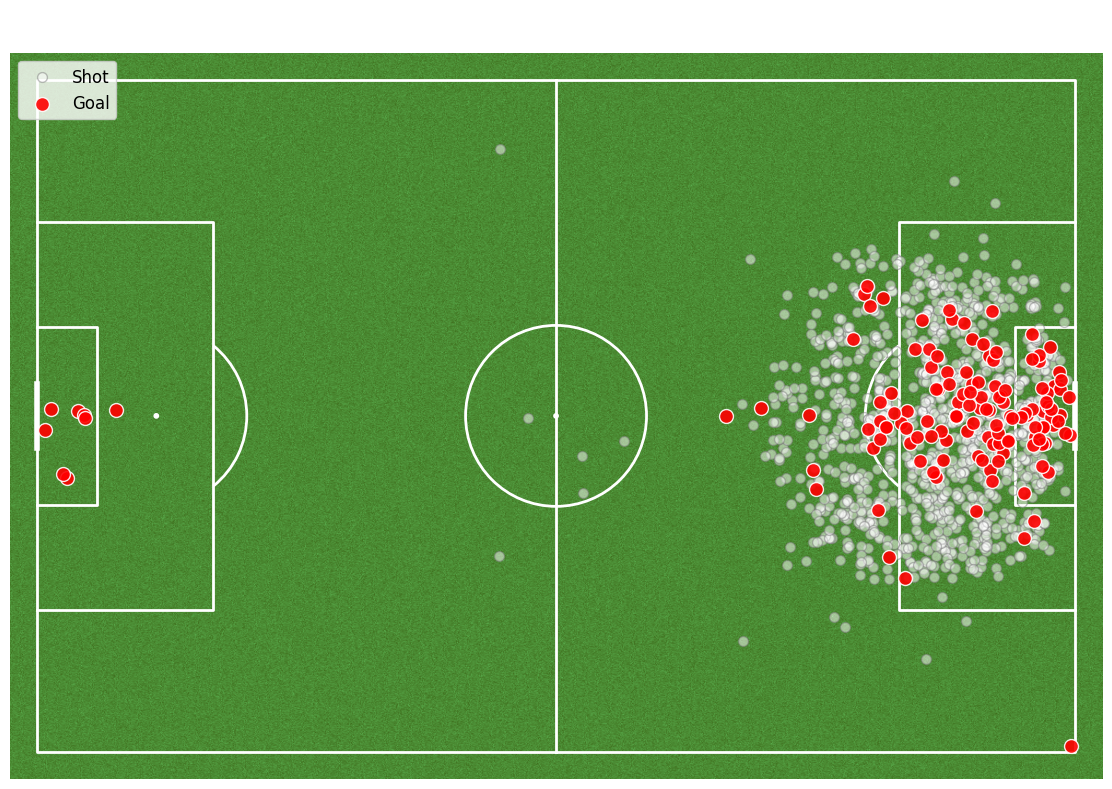

In [6]:
# Cell 5 — Shot map
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Separate goals from non-goals
goals = shots_df[shots_df['is_goal'] == True]
non_goals = shots_df[shots_df['is_goal'] == False]

# Create pitch
pitch = Pitch(pitch_type='opta', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot shots
pitch.scatter(non_goals.x, non_goals.y, ax=ax, 
              c='white', edgecolors='grey', s=50, alpha=0.5, label='Shot')
pitch.scatter(goals.x, goals.y, ax=ax,
              c='red', edgecolors='white', s=100, alpha=0.9, label='Goal')

ax.legend(loc='upper left', fontsize=12)
ax.set_title('Shot Map — All Matches', fontsize=16, color='white', pad=20)

plt.tight_layout()
plt.show()

In [7]:
# Cell 6 — Top scorers and shooters
print("=== TOP SCORERS ===")
print(shots_df[shots_df['is_goal']==True]
      .groupby('player_name')['is_goal']
      .count()
      .sort_values(ascending=False)
      .head(10))

print("\n=== MOST SHOTS ===")
print(shots_df.groupby('player_name')['is_goal']
      .count()
      .sort_values(ascending=False)
      .head(10))

print("\n=== CONVERSION RATE (min 5 shots) ===")
player_stats = shots_df.groupby('player_name').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).query('shots >= 5')
player_stats['conversion_rate'] = (player_stats['goals'] / player_stats['shots'] * 100).round(1)
print(player_stats.sort_values('conversion_rate', ascending=False).head(10))

=== TOP SCORERS ===
player_name
Viktor Gyökeres       16
Gabriel Martinelli    11
Bukayo Saka           10
Eberechi Eze           9
Leandro Trossard       8
Mikel Merino           7
Noni Madueke           7
Declan Rice            6
Martín Zubimendi       6
Gabriel Jesus          5
Name: is_goal, dtype: int64

=== MOST SHOTS ===
player_name
Bukayo Saka           98
Viktor Gyökeres       71
Leandro Trossard      69
Eberechi Eze          67
Gabriel Martinelli    54
Noni Madueke          47
Declan Rice           44
Riccardo Calafiori    38
Mikel Merino          35
Jurriën Timber        34
Name: is_goal, dtype: int64

=== CONVERSION RATE (min 5 shots) ===
                    shots  goals  conversion_rate
player_name                                      
Kai Havertz            14      4             28.6
William Saliba          8      2             25.0
Piero Hincapié          8      2             25.0
Viktor Gyökeres        71     16             22.5
Gabriel Martinelli     54     11         

In [9]:
# Cell 7 — Ask Claude to analyze the player stats
player_summary = player_stats.sort_values('goals', ascending=False).to_string()
print(analyze_dataframe(
    player_stats, 
    "Analyze these player shooting stats. Who are the most clinical finishers? Any surprising patterns? What does this tell us about Arsenal's attacking play?"
))

Looking at your shooting data, here are the key insights:

## Most Clinical Finishers
The standout efficient shooters (high conversion rates with meaningful volume):
- **Bryan Mbeumo** - 14.3% conversion rate (7 shots, 1 goal)
- **Bukayo Saka** - 10.2% conversion rate with high volume (98 shots, 10 goals)
- **Ben White** - 12.5% conversion rate (8 shots, 1 goal)

## Surprising Patterns

1. **High Volume, Zero Goals**: Players like Aleksandar Stankovic and Bruno Fernandes have taken shots but scored zero goals - this could indicate poor finishing or limited quality chances.

2. **Extreme Distribution**: The data shows a massive range - one player has 98 shots while the median is only 8 shots. This suggests either:
   - A mix of regular starters and squad players
   - Very different roles within the team

3. **Conversion Rate Ceiling**: The maximum conversion rate is 28.6%, which is excellent for football standards.

## What This Tells Us About Arsenal's Attack

**Saka is the focal point

In [10]:
# Load Bournemouth match data
from shared.db import get_engine
from shared.utils import analyze_dataframe, ask_claude
import pandas as pd

engine = get_engine()

bournemouth_df = pd.read_sql("""
    SELECT 
        me.minute,
        me.x,
        me.y,
        me.end_x,
        me.end_y,
        me.is_shot,
        me.is_goal,
        me.type_display_name,
        me.outcome_type_display_name,
        me.period_display_name,
        me.card_type,
        p.name as player_name,
        p.position,
        t.name as team_name
    FROM match_events me
    LEFT JOIN players p ON me.player_id = p.player_id
    LEFT JOIN teams t ON me.team_id = t.team_id
    LEFT JOIN matches m ON me.match_id = m.match_id
    WHERE m.match_date = '2026-04-11'
""", engine)

print(f"✅ Loaded {len(bournemouth_df):,} events")
bournemouth_df.head()

✅ Loaded 1,415 events


,minute,x,y,end_x,end_y,is_shot,is_goal,type_display_name,outcome_type_display_name,period_display_name,card_type,player_name,position,team_name
0,14,87.6,29.0,NaN,NaN,False,False,BallTouch,Successful,FirstHalf,NaN,Rayan,AMR,Bournemouth
1,14,92.9,37.4,NaN,NaN,False,False,BallTouch,Unsuccessful,FirstHalf,NaN,Junior Kroupi,AMC,Bournemouth
2,14,3.2,61.0,NaN,NaN,False,False,KeeperPickup,Successful,FirstHalf,NaN,David Raya,GK,Arsenal
3,14,8.5,63.1,31.0,63.3,False,False,Pass,Successful,FirstHalf,NaN,David Raya,GK,Arsenal
4,14,39.1,71.8,53.6,91.6,False,False,Pass,Successful,FirstHalf,NaN,Kai Havertz,AMC,Arsenal


In [11]:
print(analyze_dataframe(
    bournemouth_df,
    """
    This is event data from Arsenal vs Bournemouth on April 11 2026. 
    Arsenal lost 2-1 at home. Analyze the match — what does the data 
    tell us about why Arsenal lost? What patterns stand out in the 
    attacking and defensive play? Where did Arsenal struggle?
    """
))


Looking at this match data, I can identify several key patterns that likely contributed to Arsenal's surprising 2-1 home defeat to Bournemouth. Let me analyze the data systematically:

## Key Analysis Areas

### 1. **Shot Conversion Efficiency**
The most telling factor is likely Arsenal's finishing. With only 3 total goals in the match and Arsenal scoring just 1, this suggests poor conversion rates. In football, the team that creates chances but fails to finish them often loses to more clinical opponents.

### 2. **Territorial Control vs Results**
- **Average field position**: The overall x-coordinate average (44.6) suggests fairly balanced territorial play
- **Arsenal likely dominated possession** but couldn't convert it into goals
- This is classic Arsenal - controlling the game but lacking the killer instinct

### 3. **Defensive Vulnerabilities**
Several patterns suggest defensive issues:
- **Wide defensive gaps**: The coordinate spread shows events across the full width (0-100), in

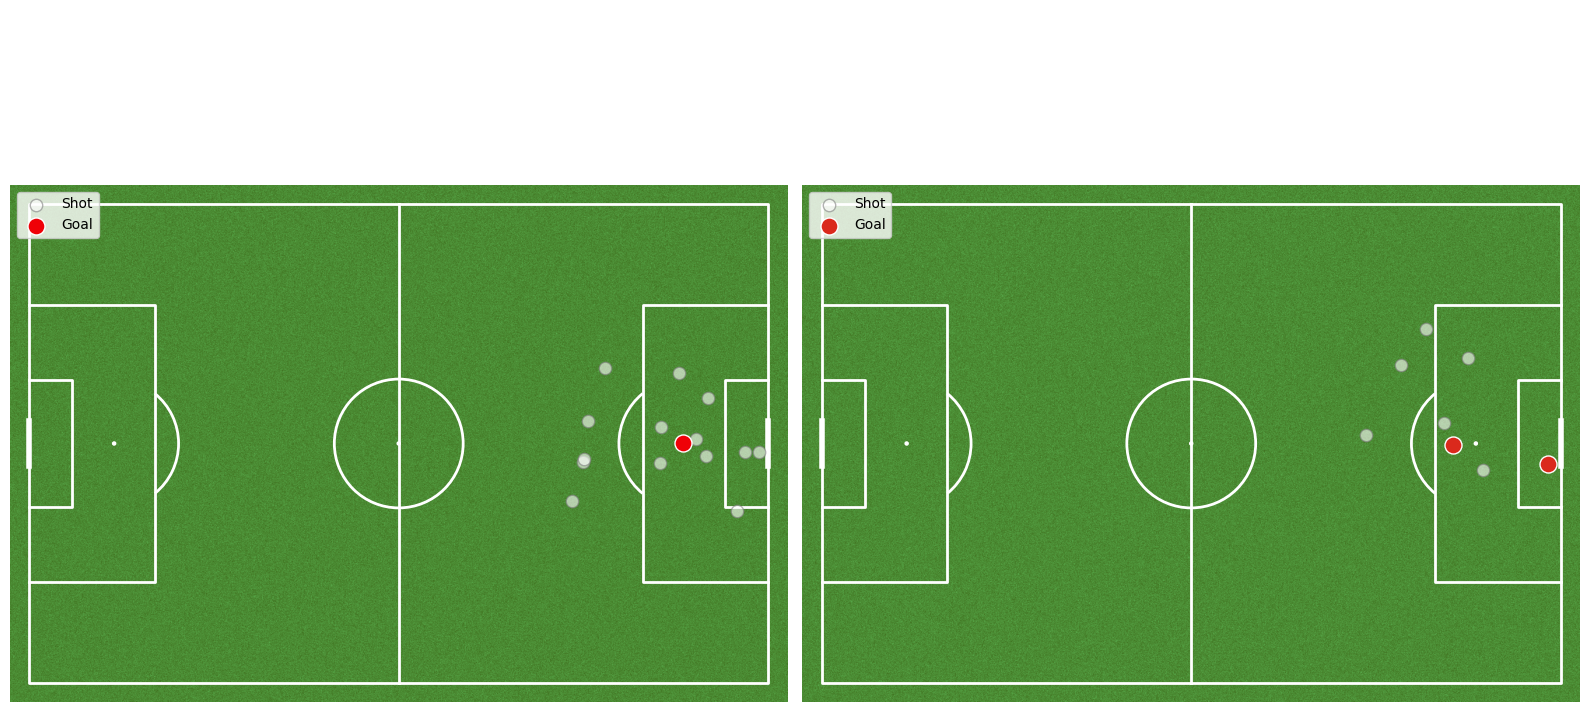

In [12]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

arsenal_id = 13  # Arsenal's team_id

arsenal_shots = bournemouth_df[
    (bournemouth_df['is_shot'] == True) & 
    (bournemouth_df['team_name'] == 'Arsenal')
]

bournemouth_shots = bournemouth_df[
    (bournemouth_df['is_shot'] == True) & 
    (bournemouth_df['team_name'] == 'Bournemouth')
]

pitch = Pitch(pitch_type='opta', pitch_color='grass', line_color='white')
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 8))

for ax, shots, team, color in [
    (axes[0], arsenal_shots, 'Arsenal', '#EF0107'),
    (axes[1], bournemouth_shots, 'Bournemouth', '#DA291C')
]:
    goals = shots[shots['is_goal'] == True]
    non_goals = shots[shots['is_goal'] == False]
    
    pitch.scatter(non_goals.x, non_goals.y, ax=ax,
                  c='white', edgecolors='grey', s=80, alpha=0.6, label='Shot')
    pitch.scatter(goals.x, goals.y, ax=ax,
                  c=color, edgecolors='white', s=150, alpha=1.0, label='Goal')
    
    ax.set_title(f'{team} Shots\n({len(goals)} goals from {len(shots)} shots)',
                 fontsize=14, color='white', pad=10)
    ax.legend(loc='upper left', fontsize=10)

plt.suptitle('Arsenal vs Bournemouth — April 11 2026', 
             fontsize=16, color='white', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
match_data_summary = """
MATCH: Arsenal vs Bournemouth, April 11 2026. Arsenal lost 2-1 at home.
ATTENDANCE: 60,210 at Emirates Stadium

GOALS FROM DATA:
- Junior Kroupi (16') - Bournemouth - x:98.2, y:45.7 - tap in from right side of goal line
- Viktor Gyökeres (34') - Arsenal - x:88.5, y:50.0 - central, just inside box
- Alex Scott (73') - Bournemouth - x:85.4, y:49.6 - edge of box centrally on counter

SHOT DATA:
- Arsenal: 23 shots, 1 goal (4.3% conversion)
- Bournemouth: fewer shots, 2 goals - clinical and efficient
- Arsenal shots clustered centrally inside box showing good positions but poor finishing

KEY TACTICAL OBSERVATIONS FROM MATCH:
1. Static movement throughout — players standing still in final third repeatedly (51', 62', 77', 87')
2. Build-up vulnerability — Raya under pressure multiple times, Gabriel risky backpass (55')
3. Midfield defensive collapse — being played through the middle repeatedly, Zubimendi exposed for 2nd goal (73') — Alex Scott ran off him
4. The 2nd goal sequence: Poor midfield movement → Gabriel turnover → ball through middle to Tavernier → Alex Scott runs off Zubimendi → scores
5. Lack of urgency out of possession — observers noted player issue not tactical
6. Bright spots: Rice driving forward, Eze work rate and control, Jesus most creative late
7. Gyökeres frustrated — offside goal disallowed (63'), missed header (91'), poor shot (93')
8. Missing Saka's quality — width and 1v1 ability absent all game
9. xG of 2.41 suggests chances created but not converted
10. Structural breakdown — CBs making attacking runs while forwards stood static (87')
"""

print(write_blog_post(
    match_data_summary,
    audience="Arsenal fans and sports analytics readers who appreciate tactical detail"
))

# When the Numbers Don't Add Up: Arsenal's Frustrating Home Defeat to Bournemouth

The Emirates Stadium has witnessed its share of head-scratching defeats, but Saturday's 2-1 loss to Bournemouth might be the most maddening yet. With over 60,000 Arsenal faithful in attendance, the Gunners managed to turn statistical dominance into sporting disaster—a masterclass in how football's beautiful unpredictability can drive you absolutely mental.

## The Tale of Two Conversion Rates

Let's start with the brutal numbers that tell the story: Arsenal peppered Bournemouth with 23 shots and managed just one goal—a woeful 4.3% conversion rate. Meanwhile, the Cherries demonstrated clinical efficiency that would make a Swiss watchmaker jealous, converting two goals from significantly fewer attempts.

Arsenal's 2.41 xG suggests they created enough quality chances to comfortably win this match. Instead, they found themselves chasing shadows and dropping precious points at home. Viktor Gyökeres' 34th-minu

In [17]:
# Check exact goal details
goals_df = bournemouth_df[bournemouth_df['is_goal'] == True][
    ['minute', 'player_name', 'team_name', 'x', 'y', 'type_display_name']
]
print(goals_df)

      minute      player_name    team_name     x     y type_display_name
284       16    Junior Kroupi  Bournemouth  98.2  45.7              Goal
507       34  Viktor Gyökeres      Arsenal  88.5  50.0              Goal
1149      73       Alex Scott  Bournemouth  85.4  49.6              Goal


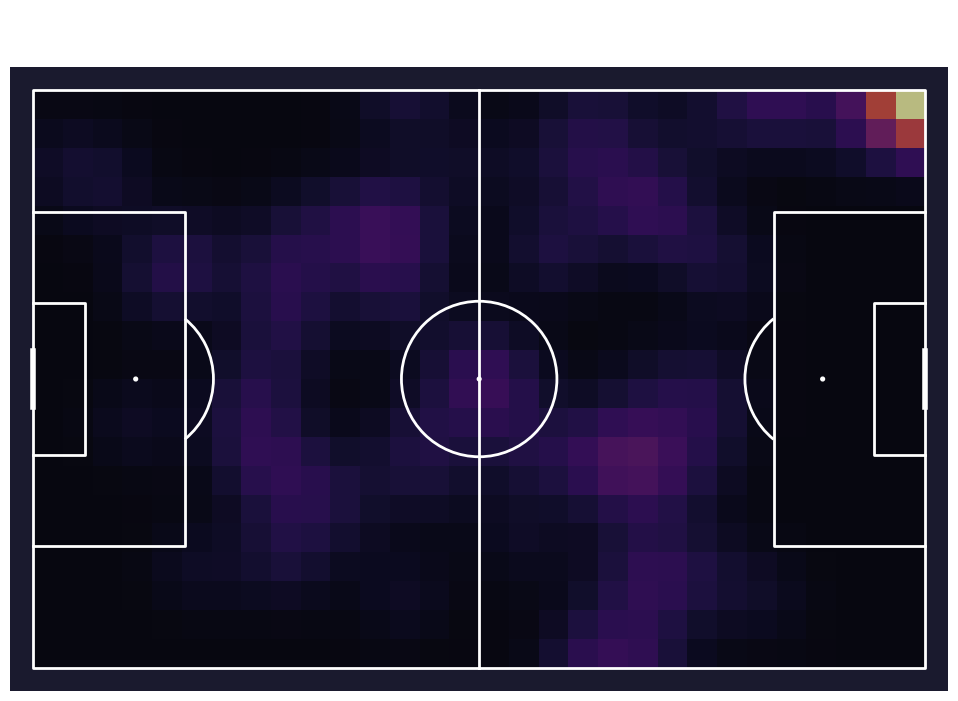

In [33]:
def plot_player_heatmap(df, player_name):
    player_df = df[df['player_name'] == player_name]
    
    # Filter out set pieces
    set_piece_types = ['CornerAwarded', 'FreekickTaken', 'KickOff']
    player_df = player_df[~player_df['type_display_name'].isin(set_piece_types)]
    
    pitch = Pitch(pitch_type='opta', pitch_color='#1a1a2e', line_color='white',
                  line_zorder=2)
    fig, ax = pitch.draw(figsize=(10, 7))
    
    bin_statistic = pitch.bin_statistic(
        player_df.x, player_df.y,
        statistic='count',
        bins=(30, 20)
    )
    
    from scipy.ndimage import gaussian_filter
    bin_statistic['statistic'] = gaussian_filter(
        bin_statistic['statistic'], sigma=1.2
    )
    
    pitch.heatmap(bin_statistic, ax=ax, cmap='inferno', 
                  edgecolors='none', alpha=0.7)
    
    ax.set_title(f'{player_name} — Open Play Touch Map\nArsenal vs Bournemouth',
                 fontsize=14, color='white', pad=15)
    
    plt.tight_layout()
    plt.show()

plot_player_heatmap(bournemouth_df, 'Declan Rice')

In [37]:
import os

output_path = os.path.join(os.path.expanduser('~'), 'sports-data-portfolio', 'data', 'bournemouth_match.csv')
bournemouth_df.to_csv(output_path, index=False)
print(f"✅ Exported {len(bournemouth_df):,} rows to {output_path}")

✅ Exported 1,415 rows to /Users/drew/sports-data-portfolio/data/bournemouth_match.csv
